**Актуализация 22.09.2026.** Production-пайплайн: RT-DETR для бутылки
и этикетки, SigLIP 2 + whitening, PaddleOCR, XFeat/RANSAC и калиброванный CatBoost classifier.
DINOv2 и прежний detector — только исторические baseline; CatBoostRanker остаётся ablation.

# Восстановление пайплайна: RT-DETR → SigLIP 2 / OCR / XFeat → CatBoost

Эксперименты выбирают настройки по validation-винам из **train**, а не по тесту.
Каждая таблица ниже читается из реального сохранённого результата. Отсутствующий артефакт
означает незавершённый шаг, а не нулевую метрику. Тестовые кадры не используются для
обучения или выбора порога. Отдельно показан текущий состав test-manifest; его нельзя менять
после просмотра итоговых метрик.

Цветной кроп остаётся входом SigLIP 2. Grayscale/CLAHE — независимые варианты веток OCR
и XFeat. Заливка добавляется **вокруг прямоугольного кропа**, когда он дополняется до квадрата;
она не закрашивает бутылку и не удаляет фон внутри её bounding box.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists(): ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from wine_scanner.embed import load_image
from wine_scanner.embed.branches import branch_image
from wine_scanner.decide.features import FEATURE_NAMES
from scripts.audit_rtdetr_crops import summarize
def read(path):
    p = ROOT / path
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None
def records(path):
    p = ROOT / path
    return [json.loads(s) for s in p.read_text(encoding='utf-8').splitlines()] if p.exists() else []
display(pd.Series(read('models/siglip2/provenance.json') or {'status':'missing'}))


G:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository                              google/siglip2-so400m-patch16-384
revision                         dd658faac399427308559e2c3ac1e99cbe43845d
model_sha256            422750e06216f053d85d4176fb6a9d4c5e71ded2d1b7c7...
verified_against_hub                                                 True
dtype: object

## 1. Переобучение этикетки и контроль численной устойчивости

Разметка перенесена вычитанием начала кропа и пересечением рамки с его границами.
Потерянную за границей часть изображения восстановить преобразованием координат нельзя.
Деление собственных кадров идёт по винам; близкие фотографии одной бутылки не должны
попадать одновременно в обучение и validation. Тест не используется для выбора эпохи.

Первый FP16-прогон дал нулевую долю детекций выше 0,3. В отдельной диагностике FP16 имел
нечисловые градиенты и пропускал шаги; BF16 на проверенных батчах имел конечные градиенты.
Это наблюдение само по себе не доказывает причину провала. Повторный прогон контролирует
градиенты и сохраняет полную историю, включая неулучшившиеся эпохи.


### Вывод раздела

BF16 и выбор checkpoint по validation закреплены потому, что первый FP16-прогон был численно нестабилен. Test не участвует в выборе эпохи.

rtdetr_label_recrop selected epoch: 1


,epoch,detection_rate,mean_iou,iou@0.75
0,1,0.0,0.0,0.0


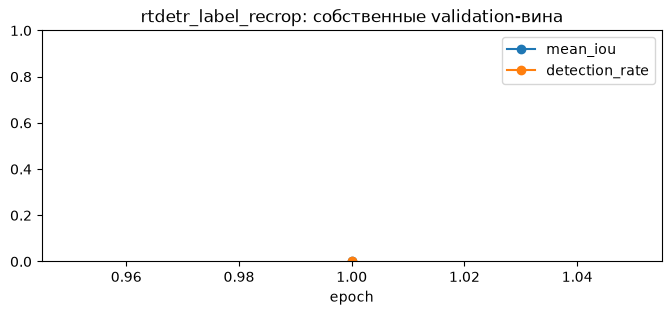

rtdetr_label_recrop_bf16 selected epoch: 4


,epoch,detection_rate,mean_iou,iou@0.75,external_valid,loss,skipped_steps,gradient_scale
0,1,1.0,0.940068,1.0,"{'detection_rate': 0.9983498349834984, 'mean_i...",12.544494,0,1.0
1,2,1.0,0.939770,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94066834...",7.569834,0,1.0
2,3,1.0,0.936759,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.93027769...",7.010296,0,1.0
3,4,1.0,0.942768,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94419395...",6.544272,0,1.0
4,5,1.0,0.936396,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94060523...",6.174730,0,1.0
5,6,1.0,0.942002,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.95035871...",5.886692,0,1.0
6,7,1.0,0.940539,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94416625...",5.596488,0,1.0


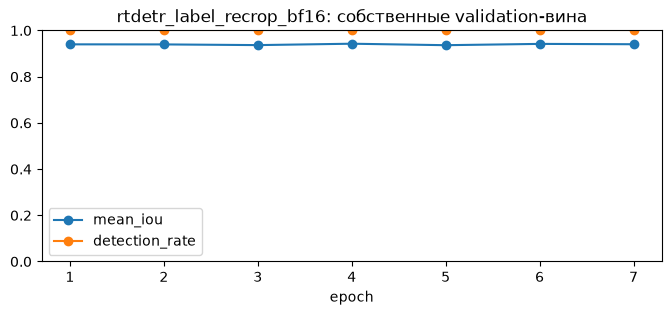

In [2]:
for folder in ('rtdetr_label_recrop', 'rtdetr_label_recrop_bf16'):
    meta = read(f'models/{folder}/training.json')
    hist = read(f'models/{folder}/history.json') or (meta or {}).get('history', [])
    print(folder, 'selected epoch:', (meta or {}).get('best_epoch', 'not ready'))
    if hist:
        frame = pd.DataFrame(hist)
        display(frame)
        frame.plot(x='epoch', y=['mean_iou','detection_rate'], marker='o', ylim=(0,1),
                   title=folder + ': собственные validation-вина', figsize=(8,3))
        plt.show()
    else: print('История ещё не готова')


## 2. Качество кропов до и после переобучения

IoU считается в координатах исходного кадра, нулевая детекция даёт IoU=0.
Fallback сохраняет всю бутылку, поэтому отсутствие детекции не означает потерю пикселей.
Здесь измеряется выбранная этикетка, **это не COCO mAP**. Несколько этикеток на полке и
единая рамка вокруг раздельных бумажных элементов требуют отдельной политики разметки.


### Вывод раздела

Кропы нужно оценивать до retrieval: потерянная этикетка не исправится embedding-моделью. Fallback сохраняет данные, но сам по себе не является успешной детекцией.

,group,images,errors,bottle_fallbacks,label_fallbacks,annotated_images,gt_labels,selected_mean_iou_frame,selected_iou_ge_50,selected_iou_ge_75,gt_retained_ge_99,gt_lost,gt_clipped,label_crop_any_gt_retained_ge_99,model
0,test/frames_annotated,332.0,0.0,42.0,4.0,145.0,145.0,0.937644,0.986207,0.972414,1.000000,0.0,0.0,NaN,baseline
1,train/frames_annotated,165.0,0.0,14.0,1.0,165.0,183.0,0.896290,0.969697,0.957576,0.956284,8.0,0.0,NaN,baseline
7,test/labels_legacy_crops,164.0,0.0,9.0,1.0,132.0,132.0,0.938308,0.992424,0.992424,1.000000,0.0,0.0,NaN,baseline
10,train/labels_legacy_crops,169.0,0.0,11.0,1.0,153.0,153.0,0.951313,1.000000,0.993464,1.000000,0.0,0.0,NaN,baseline
12,roboflow/test,309.0,0.0,14.0,0.0,309.0,319.0,0.918762,0.980583,0.944984,0.981191,1.0,5.0,NaN,baseline
13,roboflow/train,5175.0,0.0,825.0,111.0,5175.0,12476.0,0.863546,0.947826,0.895266,0.902292,665.0,554.0,NaN,baseline
14,roboflow/valid,607.0,0.0,33.0,2.0,607.0,612.0,0.921505,0.980231,0.952224,0.986928,4.0,4.0,NaN,baseline
0,test/frames_annotated,332.0,0.0,42.0,0.0,145.0,145.0,0.942917,0.993103,0.972414,1.000000,0.0,0.0,0.937931,retrained
1,train/frames_annotated,165.0,0.0,14.0,0.0,165.0,183.0,0.954150,1.000000,1.000000,0.956284,8.0,0.0,1.000000,retrained
2,test/labels_legacy_crops,164.0,0.0,9.0,0.0,132.0,132.0,0.938635,1.000000,1.000000,1.000000,0.0,0.0,0.984848,retrained


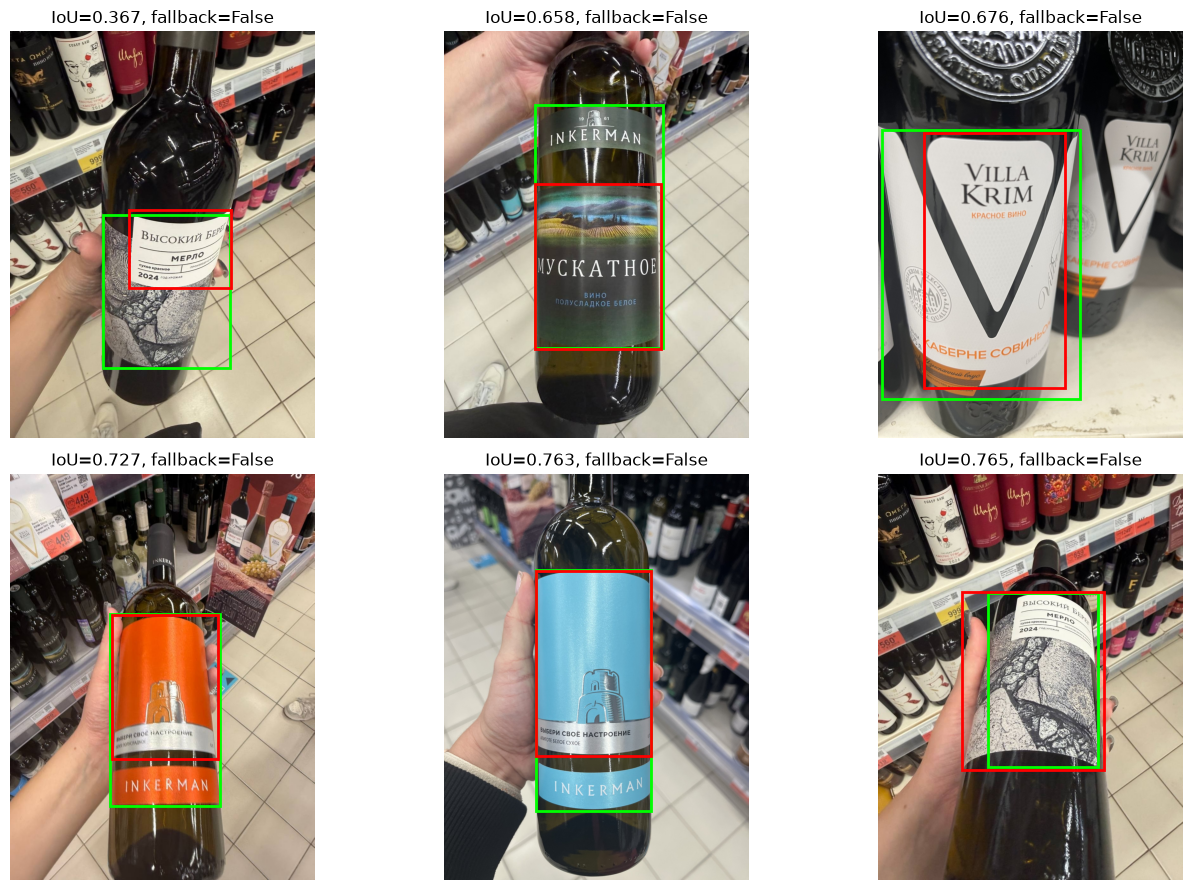

In [3]:
baseline = records('data/derived/rtdetr_audit/records.jsonl')
updated = records('data/derived/rtdetr_retrained_audit/records.jsonl')
tables = []
for name, rows in [('baseline',baseline), ('retrained',updated)]:
    if rows:
        table = pd.DataFrame(summarize(rows)).T
        table['model'] = name
        tables.append(table.reset_index(names='group'))
if tables:
    comparison = pd.concat(tables)
    display(comparison[comparison.annotated_images > 0])
if updated:
    chosen = sorted([r for r in updated if r['group']=='test/frames_annotated' and r['gt_labels']],
                    key=lambda r:r['selected_label_iou_frame'])[:6]
    from matplotlib.patches import Rectangle
    fig, axes = plt.subplots(2,3,figsize=(14,9))
    for ax,r in zip(axes.flat,chosen):
        ax.imshow(load_image(r['source']))
        for box in r['gt_labels']:
            x,y,x2,y2=box
            ax.add_patch(Rectangle((x,y),x2-x,y2-y,fill=False,color='lime',lw=2))
        if r['selected_label_frame']:
            x,y,x2,y2=r['selected_label_frame']
            ax.add_patch(Rectangle((x,y),x2-x,y2-y,fill=False,color='red',lw=2))
        ax.set_title(f"IoU={r['selected_label_iou_frame']:.3f}, fallback={r['label_fallback']}")
        ax.axis('off')
    plt.tight_layout(); plt.show()
else: print('Обновлённый аудит ещё не выполнен')


## 3. Цвет полей вокруг кропа

Один и тот же цвет применяется к каталогу и запросам. Мера выбора — средний Recall@1
по винам, при равенстве Recall@5; при полном равенстве остаётся прежняя настройка.
На малом числе вин разница в один кадр — слабое доказательство. Это ablation визуального
поиска, а не итоговая точность всего сервиса.


### Вывод раздела

Padding — часть пространства признаков, поэтому он должен быть одинаков у запросов и карточек. Победитель определяется wine-macro validation, не единичным кадром.

In [4]:
for filename in ('padding_validation.json','padding_retrained_validation.json'):
    report=read('data/derived/'+filename)
    if report:
        print(filename, 'selection:', report['selection'], 'wines:',report['validation_wines'])
        display(pd.DataFrame(report['results']).T)


padding_validation.json selection: white wines: ['Baron_Philippe_de_Rothschild_MoutonCadet_2022_bordeaux_red', 'Baron_Philippe_de_Rothschild_MoutonCadet_2023_bordeaux_white', 'Chateau_Tamagne_красное_2025', 'Ff_Clou_du_pin_chateau_2021_bordeaux_superieur_premium', 'Ladofoods_Vang_Dalat_export_white_wine']


,fill,queries,catalog,r1,r5,wine_macro_r1,wine_macro_r5
current,"[124, 116, 104]",30,20,0.766667,0.933333,0.76,0.933333
neutral,"[128, 128, 128]",30,20,0.766667,0.933333,0.76,0.933333
white,"[255, 255, 255]",30,20,0.8,0.933333,0.8,0.933333
black,"[0, 0, 0]",30,20,0.766667,0.933333,0.771429,0.933333


padding_retrained_validation.json selection: white wines: ['Baron_Philippe_de_Rothschild_MoutonCadet_2022_bordeaux_red', 'Ff_Clou_du_pin_chateau_2021_bordeaux_superieur_premium', 'Ladofoods_Excellence_sauvignon_blanc_white_wine', 'Ladofoods_Vang_Dalat_classic_special_red_wine']


,fill,queries,catalog,r1,r5,wine_macro_r1,wine_macro_r5
current,"[124, 116, 104]",24,20,0.833333,1.0,0.833333,1.0
neutral,"[128, 128, 128]",24,20,0.833333,1.0,0.833333,1.0
white,"[255, 255, 255]",24,20,0.875,1.0,0.875,1.0
black,"[0, 0, 0]",24,20,0.875,1.0,0.875,1.0


## 4. RGB, grayscale и CLAHE — отдельные эксперименты для OCR и XFeat

Для выбора OCR основной критерий — macro R@5, затем R@1: в CatBoost идут пять текстовых
кандидатов. Для XFeat основной критерий — macro R@1, затем R@5 по числу
RANSAC-инлаеров. Равные нулевые оценки считаются неудачей, а не удачным первым местом.
Название из БД не является полной посимвольной транскрипцией фото: `cer_proxy` — только
диагностический показатель, его нельзя выдавать за настоящий OCR CER.

CLAHE усиливает локальный контраст, но может усилить блики, фактуру бумаги и шум.
Поэтому увеличение числа совпадений без улучшения ранга правильного вина — не победа.


### Вывод раздела

RGB остаётся вариантом OCR, а CLAHE проверяется для XFeat отдельно. Выбор по recall и bootstrap-интервалам защищает от ложного выигрыша на нескольких похожих снимках.

baseline 30 queries; 5 wines


,text_macro_r1,text_macro_r5,geometry_macro_r1,geometry_macro_r5,mean_true_inliers,seconds
rgb,0.482857,0.764762,0.860000,0.926667,614.833333,427.814517
gray,0.454286,0.764762,0.893333,0.893333,612.200000,418.109721
clahe2,0.416190,0.798095,0.860000,0.860000,614.700000,372.375389
clahe4,0.416190,0.764762,0.860000,0.893333,609.266667,288.315252


Выбор OCR: preliminary XFeat: preliminary


,true_inliers,true_inlier_ratio,true_reprojection
mode,,,
clahe2,390.0,0.627362,1.912276
clahe4,375.5,0.607284,1.949918
gray,376.5,0.628207,1.858278
rgb,383.0,0.629466,1.875680


queries  geometry_r1  text_r5  median_inlier_ratio  \
mode   condition                                                       
clahe2 angle            5          1.0      1.0             0.479268   
       blur             5          0.6      0.0             0.385827   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.8             0.644315   
       glare            6          1.0      1.0             0.569450   
       partial          4          1.0      1.0             0.802848   
clahe4 angle            5          1.0      1.0             0.438750   
       blur             5          0.6      0.0             0.500000   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.6             0.604520   
       glare            6          1.0      1.0             0.556063   
       partial          4          1.0      1.0             0.792226   
gray   angle            5          1.0      1.0             0.447761   
       blur             5          0.8      0.0             0.416667   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.6             0.614776   
       glare            6          1.0      1.0             0.615357   
       partial          4          1.0      1.0             0.817403   
rgb    angle            5          1.0      1.0             0.413366   
       blur             5          0.6      0.0             0.500000   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.6             0.578811   
       glare            6          1.0      1.0             0.624576   
       partial          4          1.0      1.0             0.817094   

                  median_reprojection  
mode   condition                       
clahe2 angle                 2.093292  
       blur                  2.255045  
       catalog               0.000000  
       far                   1.580660  
       glare                 1.912276  
       partial               1.879336  
clahe4 angle                 2.062136  
       blur                  2.237728  
       catalog               0.000000  
       far                   1.657418  
       glare                 2.016136  
       partial               1.878388  
gray   angle                 2.032723  
       blur                  2.223927  
       catalog               0.000000  
       far                   1.448161  
       glare                 2.018793  
       partial               1.854301  
rgb    angle                 2.076632  
       blur                  1.893820  
       catalog               0.000000  
       far                   1.628617  
       glare                 2.076674  
       partial               1.860260

...

,text_macro_r1,text_macro_r5,geometry_macro_r1,geometry_macro_r5,mean_true_inliers,seconds
rgb,0.541667,0.791667,0.916667,0.958333,599.000000,18.262147
gray,0.500000,0.791667,0.875000,0.958333,598.875000,14.647652
clahe2,0.458333,0.791667,0.916667,1.000000,586.625000,15.195982
clahe4,0.375000,0.708333,0.916667,1.000000,578.958333,14.991553


Выбор OCR: rgb XFeat: clahe2


,delta_vs_rgb,ci95
rgb:text_rank:r5,0.0,"[0.0, 0.0]"
gray:text_rank:r5,0.0,"[0.0, 0.0]"
clahe2:text_rank:r5,0.0,"[0.0, 0.0]"
clahe4:text_rank:r5,-0.083333,"[-0.16666666666666674, 0.0]"
rgb:geometry_rank:r1,0.0,"[0.0, 0.0]"
gray:geometry_rank:r1,-0.041667,"[-0.12499999999999997, 0.0]"
clahe2:geometry_rank:r1,0.0,"[-0.12499999999999997, 0.12500000000000006]"
clahe4:geometry_rank:r1,0.0,"[0.0, 0.0]"


,true_inliers,true_inlier_ratio,true_reprojection
mode,,,
clahe2,328.5,0.652004,2.026800
clahe4,336.5,0.596122,2.098055
gray,374.5,0.643389,2.010710
rgb,382.0,0.632298,1.956645


queries  geometry_r1  text_r5  median_inlier_ratio  \
mode   condition                                                       
clahe2 angle            4         1.00     1.00             0.486017   
       blur             4         0.75     0.00             0.411416   
       catalog          4         1.00     1.00             1.000000   
       far              4         1.00     0.75             0.671929   
       glare            4         0.75     1.00             0.490992   
       partial          4         1.00     1.00             0.738588   
clahe4 angle            4         1.00     1.00             0.464965   
       blur             4         0.75     0.00             0.387343   
       catalog          4         1.00     1.00             1.000000   
       far              4         1.00     0.25             0.621809   
       glare            4         0.75     1.00             0.424262   
       partial          4         1.00     1.00             0.705698   
gray   angle            4         1.00     1.00             0.509519   
       blur             4         0.75     0.00             0.434969   
       catalog          4         1.00     1.00             1.000000   
       far              4         0.75     0.75             0.695020   
       glare            4         0.75     1.00             0.517570   
       partial          4         1.00     1.00             0.802723   
rgb    angle            4         1.00     1.00             0.526679   
       blur             4         0.75     0.00             0.476191   
       catalog          4         1.00     1.00             1.000000   
       far              4         1.00     0.75             0.683393   
       glare            4         0.75     1.00             0.486124   
       partial          4         1.00     1.00             0.807828   

                  median_reprojection  
mode   condition                       
clahe2 angle             2.042041e+00  
       blur              2.057622e+00  
       catalog           0.000000e+00  
       far               2.165212e+00  
       glare             2.185361e+00  
       partial           2.026800e+00  
clahe4 angle             2.195464e+00  
       blur              2.182841e+00  
       catalog           1.672040e-20  
       far               2.138478e+00  
       glare             2.195676e+00  
       partial           2.074005e+00  
gray   angle             2.057301e+00  
       blur              2.163592e+00  
       catalog           0.000000e+00  
       far               1.890666e+00  
       glare             2.081822e+00  
       partial           1.900889e+00  
rgb    angle             2.241759e+00  
       blur              2.018567e+00  
       catalog           1.759994e-19  
       far               1.865031e+00  
       glare             2.022242e+00  
       partial           1.988860e+00

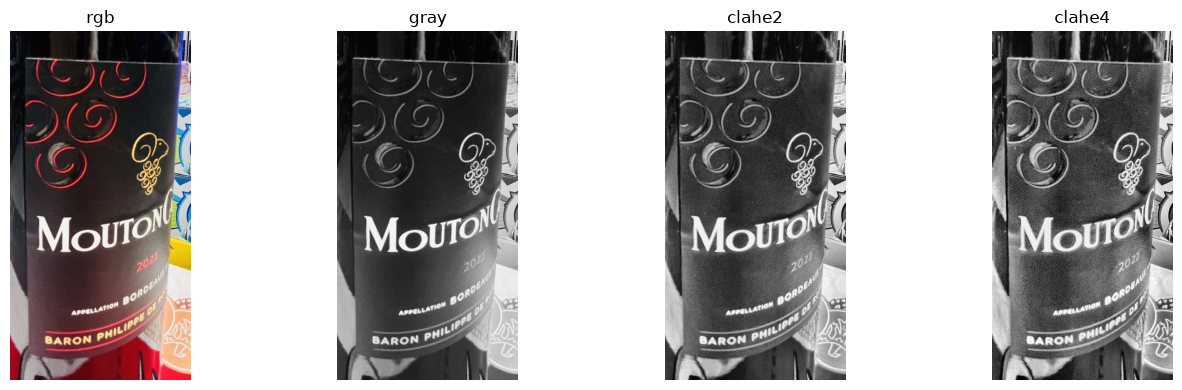

In [5]:
branch_reports={}
for tag in ('baseline','retrained'):
    report=read(f'data/derived/branches_{tag}.json')
    if report:
        branch_reports[tag]=report
        print(tag, report['queries'], 'queries;',len(report['validation_wines']),'wines')
        display(pd.DataFrame(report['summary']).T)
        print('Выбор OCR:',report.get('selected_ocr','preliminary'),
              'XFeat:',report.get('selected_local','preliminary'))
        if report.get('paired_wine_bootstrap'):
            display(pd.DataFrame(report['paired_wine_bootstrap']).T)
        table=pd.DataFrame(report['records'])
        display(table.groupby('mode')[['true_inliers','true_inlier_ratio','true_reprojection']].median())
        table['condition']=table['query'].map(lambda p:Path(p).stem.split('_')[0])
        table['geometry_top1']=table.geometry_rank <= 1
        table['text_top5']=table.text_rank <= 5
        display(table.groupby(['mode','condition']).agg(
            queries=('wine','size'), geometry_r1=('geometry_top1','mean'),
            text_r5=('text_top5','mean'), median_inlier_ratio=('true_inlier_ratio','median'),
            median_reprojection=('true_reprojection','median')))
rows=updated or baseline
examples=[r for r in rows if r.get('group')=='train/frames_annotated' and not r.get('error')]
if examples:
    image=load_image(examples[0]['label_crop'])
    fig,axes=plt.subplots(1,4,figsize=(14,4))
    for ax,mode in zip(axes,('rgb','gray','clahe2','clahe4')):
        ax.imshow(branch_image(image,mode));ax.set_title(mode);ax.axis('off')
    plt.tight_layout();plt.show()


## 5. Цилиндрическая этикетка и геометрические признаки

Гомография точно описывает перспективу плоскости. Вся поверхность цилиндра плоскостью
не является; одна гомография может подтвердить центральный участок и отвергнуть края.
Поэтому CatBoost получает не только число инлаеров, но и их долю, площадь покрытия
кропа и ошибку репроекции, нормированную на диагональ изображения.

Автоматическая развёртка требует оценки оси, радиуса и положения камеры. Ошибочная
развёртка сама деформирует буквы. Пока нет отдельного замера на размеченных ракурсах,
включать её постоянно нельзя. Следующий обоснованный эксперимент — отдельные группы
фронтальных и боковых кадров, затем проверка выигрыша развёртки на отложенных винах.

[OpenCV: область применимости гомографии](https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html).


### Вывод раздела

Одна гомография не моделирует цилиндрическую поверхность бутылки. Пока развёртка не доказала выигрыш на отложенных ракурсах, в production остаются измеримые RANSAC-признаки.

## 6. Что получает CatBoost

FAISS IndexFlatIP возвращает скалярное скалярное произведение нормированных эмбеддингов:
это cosine similarity; `1 − similarity` — cosine distance. Дополнительно идут ранг,
разрыв между первым и вторым кандидатом, среднее и разброс сходства. Координаты
1152-мерного эмбеддинга и матрица гомографии в матрицу CatBoost не включены.

Текстовые признаки: нормированное расстояние Левенштейна, Jaro–Winkler, совпадение лучшей
OCR-строки, token-set ratio, пять скоров текстовой выдачи и ранг текущего кандидата.
Отсутствие OCR — пропущенная информация, а не идеальное совпадение двух пустых строк.

CatBoost не гарантированно лучше другого бустинга только из-за разнородности признаков:
большинство наших входов уже числовые. Здесь это выбранный алгоритм, а качество подтверждает
групповая out-of-fold оценка и отдельный тест. Калибровка относится к победителю выдачи;
OOF-числа после подбора порога — диагностические, независимую оценку даёт финальный тест.


### Вывод раздела

Production использует калиброванный CatBoost classifier на числовых cross-modal признаках. CatBoostRanker v4 — ablation: он не активируется, пока не превзойдёт classifier на OOF и независимой проверке.

In [6]:
print('Число признаков:',len(FEATURE_NAMES))
display(pd.DataFrame({'feature':FEATURE_NAMES}))
for path in ('models/index_platform/config.json','models/decider_platform_paddle/meta.json'):
    value=read(path)
    print(path)
    display(pd.Series(value if value else {'status':'artifact not ready'}))
for path in sorted((ROOT/'eval/results').glob('*recrop*.json')):
    print(path.name)
    display(pd.Series(read(path)))


Число признаков: 47


,feature
0,vis_score
1,vis_rank
2,txt_score
3,txt_rank
4,rrf_rank
5,matches
6,inliers
7,inlier_ratio
8,reproj_error
9,homography_ok


models/index_platform/config.json


model                                                      models/siglip2
embedding_sha256        422750e06216f053d85d4176fb6a9d4c5e71ded2d1b7c7...
embedding_provenance    {'repository': 'google/siglip2-so400m-patch16-...
label_sha256            7ccf4ac0f3e938f5b7baeea8b12c5d1891361a8f2c831b...
detect                                                            cascade
detector                                                           rtdetr
bottle_model                                         PekingU/rtdetr_r18vd
fit                                                                   pad
weights                                   models\rtdetr_label_recrop_bf16
catalog                                                          platform
items                                                                2103
size                                                                  384
descriptor                                                         pooled
dim                                   

models/decider_platform_paddle/meta.json


backend                                                        catboost
calib_weight                                                   0.716218
calib_bias                                                    -1.336051
threshold                                                          0.03
feature_names         [vis_score, vis_rank, txt_score, txt_rank, rrf...
feature_version                                                       3
trained_on                  eval\results\features_platform_paddle.jsonl
holdout_isolated                                                   True
queries                                                             480
unknown_queries                                                     174
wines                                                               335
oof_top1                                                       0.545752
family_map                                                         None
auroc_unknown         {'family': 0.6870060660429749, 'nofamily':

features_platform_recrop.meta.json


feature_version                                                     3
feature_names       [vis_score, vis_rank, txt_score, txt_rank, rrf...
pipeline_version           {'index': 'f21a3759ed7d', 'decider': None}
index_config        {'model': 'models/siglip2', 'embedding_sha256'...
sources                                            [synthetic, train]
dtype: object

## 7. Финальный сквозной прогон

`final_top1` — правильность лидера среди известных вин, до отказа.
`coverage` — доля известных запросов, на которые система ответила.
`answered_precision` относится только к известным винам; `overall_answered_precision`
учитывает также ошибочные ответы на незнакомые вина. Их нельзя смешивать.
`false_accept` — доля незнакомых запросов, получивших чужую карточку.
Задержка финального прогона измеряется без кэшей готового OCR и кропов.


### Вывод раздела

Итоговый benchmark разделяет known accuracy, coverage и false accept unknown. Последняя величина — главный риск текущей системы, её нельзя маскировать общей точностью.

rtdetr-recrop-catboost-paddle-v1-current-test 2026-09-21T14:28:58


,value
known,93.000000
unknown,102.000000
long_list_hit,1.000000
window_hit,1.000000
guard_fired_known,3.000000
guard_fired_unknown,24.000000
sibling_swaps_known,9.000000
sibling_swaps_unknown,28.000000
rerank_top1,0.569892
final_top1,0.892473


,p50_ms,p95_ms
crop,123.3264,142.0935
embed,61.4741,109.4831
search,0.2684,0.3283
rerank,2033.4633,3318.3721
ocr,1224.0956,2451.0433
text_search,2.9008,4.3652
signals,1.7058,2.7355
vintage,0.0418,127.7378
decide,7.2227,11.0486
total,2281.8628,3627.6088


,wine_id,known,n,source,answered,vis_rank_median,txt_rank_median,window_hit,rerank_top1,final_top1,correct,twin,group,best
0,abrau-dyurso-az-abrau-madrasa-krasnoe-suhoe-14,True,1,live,1,0.0,0.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN
1,abrau-dyurso-imperatorskoe-bryut-shardone-belo...,True,2,live,2,0.0,7.0,2.0,2.0,2.0,2.0,0.0,NaN,NaN
2,abrau-dyurso-imperatorskoe-polusladkoe-shardon...,True,2,live,2,0.0,0.5,2.0,2.0,2.0,2.0,0.0,NaN,NaN
3,abrau-dyurso-russkoe-igristoe-polusladkoe-shar...,True,1,live,1,0.0,0.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN
4,abrau-dyurso-russkoe-igristoe-polusuhoe-rozovo...,True,2,live,2,0.0,0.0,2.0,2.0,2.0,2.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,unknown-valeriy-zaharin-risling-suhoe-2024,False,2,live,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown-hard,valeriy-zaharin-risling-valeriy-zaharin-rislin...
102,unknown-vedernikov-kaberne-tsimlyanskiy-krasno...,False,1,live,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown-hard,vinodelnya-vedernikov-vedernikov-dolina-dona-k...
103,unknown-villa-krim-kaberne-sovinon-krasnoe,False,1,live,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown-hard,villa-di-alma-pti-verdo-krasnoe-suhoe-125
104,unknown-villa-krim-sovinon-beloe,False,3,live,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown-hard,villa-sofiya-sovinon-blan-beloe-suhoe-123


Slug-only: метрика заказчика для изображений вин из каталога


n                     93.000000
retrieval_top1         0.892473
answer_coverage        0.978495
answered_correct      83.000000
correct_slug_rate      0.892473
answered_precision     0.912088
wrong_or_twin          8.000000
refused                2.000000
Name: value, dtype: float64

,path,wine_id,true_id,known,answered,group,vis_rank,txt_rank,in_long_list,in_window,guard,rerank_top1,final_top1,verdict,best_id,probability
0,data\test\unknown-massandra-portveyn-rozovyy-a...,unknown-massandra-portveyn-rozovyy-alushta-2023,unknown:unknown-massandra-portveyn-rozovyy-alu...,False,True,unknown-hard,1000000,1000000,False,False,sibling,False,False,accepted,massandra-rozovoe-suhoe,0.598584
1,data\test\unknown-massandra-portveyn-rozovyy-a...,unknown-massandra-portveyn-rozovyy-alushta-2023,unknown:unknown-massandra-portveyn-rozovyy-alu...,False,True,unknown-hard,1000000,1000000,False,False,sibling,False,False,accepted,massandra-rozovoe-suhoe,0.498897
2,data\test\unknown-massandra-portveyn-rozovyy-a...,unknown-massandra-portveyn-rozovyy-alushta-2023,unknown:unknown-massandra-portveyn-rozovyy-alu...,False,True,unknown-hard,1000000,1000000,False,False,sibling,False,False,accepted,massandra-rozovoe-suhoe,0.062707
6,data\test\massandra-portveyn-krasnyy-alushta\I...,massandra-portveyn-krasnyy-alushta,massandra-portveyn-krasnyy-alushta-krasnye-sor...,True,True,live,2,0,True,True,NaN,False,False,twin,massandra-portveyn-krasnyy-livadiya-kaberne-so...,0.206271
7,data\test\massandra-portveyn-belyy-krymskiy\IM...,massandra-portveyn-belyy-krymskiy,massandra-portveyn-belyy-krymskiy-kokur-beloe-...,True,True,live,1,0,True,True,NaN,False,False,twin,massandra-portveyn-belyy-gurzuf-kokur-belyy-be...,0.217030
8,data\test\massandra-portveyn-belyy-krymskiy\IM...,massandra-portveyn-belyy-krymskiy,massandra-portveyn-belyy-krymskiy-kokur-beloe-...,True,False,live,1,34,True,True,sibling,False,False,refused,massandra-rozovoe-suhoe,0.021757
22,data\test\abrau-dyurso-russkoe-igristoe-polusu...,abrau-dyurso-russkoe-igristoe-polusuhoe-shardo...,abrau-dyurso-russkoe-igristoe-polusuhoe-shardo...,True,True,live,1,0,True,True,sibling,True,False,twin,abrau-dyurso-abrau-dyurso-pino-nuar-krasnoe-su...,0.280777
23,data\test\abrau-dyurso-victor-dravigny-bryut\I...,abrau-dyurso-victor-dravigny-bryut,abrau-dyurso-victor-dravigny-bryut,True,True,live,5,1,True,True,NaN,False,False,twin,abrau-dyurso-victor-dravigny-brut-shardone-bel...,0.126442
24,data\test\abrau-dyurso-victor-dravigny-bryut\I...,abrau-dyurso-victor-dravigny-bryut,abrau-dyurso-victor-dravigny-bryut,True,True,live,2,1,True,True,sibling,False,False,twin,abrau-dyurso-victor-dravigny-brut-shardone-bel...,0.049187
35,data\test\chateau-de-talu-uroki-frantsuzskogo-...,chateau-de-talu-uroki-frantsuzskogo-kaberne-so...,chateau-de-talu-uroki-frantsuzskogo-kaberne-so...,True,True,live,1,0,True,True,NaN,True,False,twin,chateau-de-talu-uroki-frantsuzskogo-sovinon-bl...,0.343574


Wine-macro top1: 0.8996913580246914 95% wine bootstrap: [0.82098765 0.96296296]


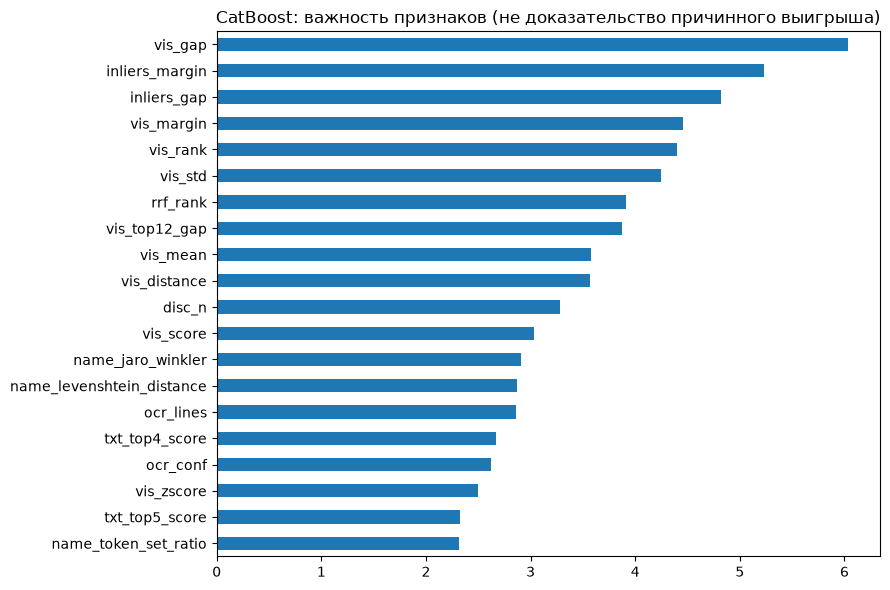

In [7]:
runs=records('eval/results/platform_recrop_runs.jsonl')
if runs:
    # This is the completed manifest after removing the photos that no longer exist.
    # ``warn`` returns the nearest catalogue card and keeps twin evidence as a warning.
    current_tag = 'rtdetr-recrop-catboost-paddle-v1-current-test'
    run = next((r for r in reversed(runs) if r['tag'] == current_tag), runs[-1])
    print(run['tag'],run['timestamp'])
    display(pd.json_normalize(run['metrics']).T.rename(columns={0:'value'}))
    display(pd.DataFrame(run['latency']).T)
    display(pd.DataFrame(run['per_wine']))
    slug = run['metrics'].get('slug_only')
    if slug:
        print('Slug-only: метрика заказчика для изображений вин из каталога')
        display(pd.Series(slug).rename('value'))
    out=pd.DataFrame(records('eval/results/platform_recrop_outcomes_paddle_current_test.jsonl'))
    if len(out):
        errors=out[(out.known & ~out.final_top1) | (~out.known & out.answered)]
        display(errors)
        known=out[out.known].groupby('wine_id').final_top1.mean()
        if len(known):
            rng=np.random.default_rng(2026)
            boot=rng.choice(known.to_numpy(),size=(2000,len(known)),replace=True).mean(axis=1)
            print('Wine-macro top1:',known.mean(),
                  '95% wine bootstrap:',np.quantile(boot,[.025,.975]))
else: print('Финальный сквозной прогон ещё не выполнен; исторические метрики не подставляем.')
meta=read('models/decider_platform_paddle/meta.json')
if meta and meta.get('feature_importance'):
    pd.Series(meta['feature_importance']).nlargest(20).sort_values().plot.barh(
        figsize=(9,6),title='CatBoost: важность признаков (не доказательство причинного выигрыша)')
    plt.tight_layout();plt.show()


## 8. Инференс трёх кадров организаторов и собственный запрос

Ниже выполняется **тот же** `WineScanner`, что использует benchmark. У `eval` нет правильных
slug в репозитории, поэтому результаты этих трёх изображений — qualitative review, а не
метрика. Ячейка `CUSTOM_IMAGE` вынесена отдельно: замените путь на любой локальный файл и
выполните её. Не добавляйте этот файл в train или калибровку только потому, что уже увидели
ответ модели.


### Вывод раздела

Инференс следует показывать вместе с исходной этикеткой, slug, probability, guard и карточками-кандидатами. Для неизвестного вина корректен отказ с похожими, а не чужой slug.

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loading weights:  98%|█████████▊| 517/526 [00:00<00:00, 5149.10it/s]

Loading weights: 100%|██████████| 526/526 [00:00<00:00, 5123.25it/s]

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 526/526 [00:00<00:00, 5276.60it/s]

...

Creating model: ('PP-OCRv5_mobile_det', None)


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prowe\.paddlex\official_models\PP-OCRv5_mobile_det`.


G:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Creating model: ('eslav_PP-OCRv5_mobile_rec', None)


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prowe\.paddlex\official_models\eslav_PP-OCRv5_mobile_rec`.


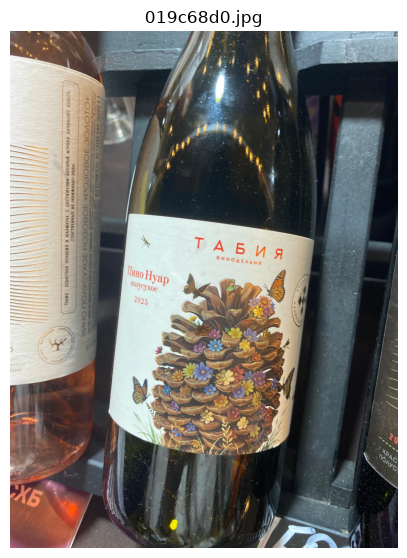

Ответ: False best: usadba-mezyb-usadba-mezyb-shardone-beloe-suhoe-125 p= 0.0088 threshold= 0.03 guard= twin_warning
OCR: ТАБИЯ ВИНОДЕЛЬНЯ ПиноНуар полусухое 2025


,item_id,probability,winery,name
0,usadba-mezyb-usadba-mezyb-shardone-beloe-suhoe...,0.008778,Усадьба Мезыбь,Усадьба Мезыбь. Шардоне
1,usadba-mezyb-usadba-mezyb-roze-kaberne-sovinon...,0.004760,Усадьба Мезыбь,Усадьба Мезыбь. Розе Каберне Совиньон
2,usadba-mezyb-usadba-mezyb-vione-beloe-suhoe-118,0.004610,Усадьба Мезыбь,Усадьба Мезыбь. Вионье
3,usadba-mezyb-usadba-mezyb-kaberne-sovinon-kras...,0.004137,Усадьба Мезыбь,Усадьба Мезыбь. Каберне Совиньон
4,usadba-mezyb-usadba-mezyb-merlo-krasnoe-suhoe-15,0.003531,Усадьба Мезыбь,Усадьба Мезыбь. Мерло


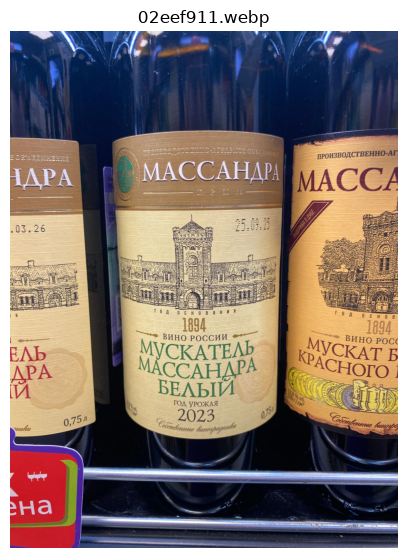

Ответ: True best: massandra-muskatel-belyy-belye-sorta-vinograda-beloe-sladkoe-16 p= 0.3328 threshold= 0.03 guard= sibling
OCR: MACCAHAPA 25.1.1 1894 МУСКАТЕЛЬ ВИНО РОССИИ БЕЛЫЙ ГОД УРОЖАЯ 2023


,item_id,probability,winery,name
0,massandra-muskatel-belyy-belye-sorta-vinograda...,0.332796,Массандра,Мускатель белый
1,massandra-muskat-belyy-yuzhnoberezhnyy-beloe-s...,0.332796,Массандра,Мускат Белый Южнобережный
2,massandra-portveyn-belyy-gurzuf-kokur-belyy-be...,0.003802,Массандра,Портвейн Белый Гурзуф
3,aratti-muskat-belyj-suhoe,0.002511,АРАТТИ,АРАТТИ Мускат белый сухое
4,massandra-muskat-belyy-pozdnego-sbora-beloe-sl...,0.000877,Массандра,Мускат белый позднего сбора


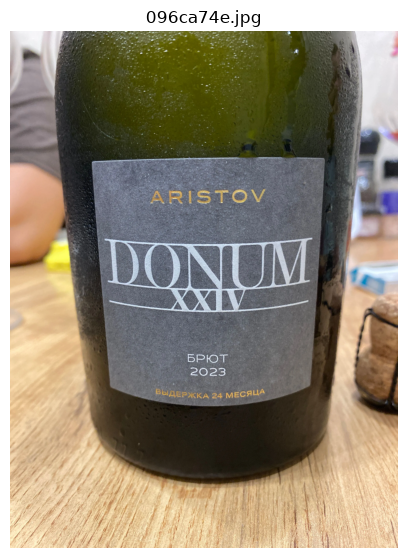

Ответ: False best: fanagoriya-blanc-de-blancs-shardone-beloe-bryut-12 p= 0.001 threshold= 0.03 guard= twin_warning
OCR: ARISTOV DONUM XXIV БРЮТ 2023


,item_id,probability,winery,name
0,fanagoriya-blanc-de-blancs-shardone-beloe-bryu...,0.001026,Фанагория,Blanc de Blancs
1,fanagoriya-primum-alveus-brut-2021-shardone-be...,0.000853,Фанагория,Primum Alveus. Brut 2021
2,aristov-anima-millesimato-beloe-bryut,0.000792,Кубань-Вино,Аристов ANIMA Millesimato белое брют
3,aristov-anima-millesimato,0.000634,Кубань-Вино,Аристов Anima Millesimato
4,kuban-vino-aristov-sandzhoveze-krasnoe-suhoe-13,0.000505,Кубань-Вино,Аристов Санджовезе


In [8]:
from wine_scanner.pipeline import WineScanner

scanner = WineScanner(
    index_dir=ROOT/'models/index_platform',
    decider_dir=ROOT/'models/decider_platform_paddle',
    crop_cache=None,
)

def show_inference(path):
    path = Path(path)
    result = scanner.identify(load_image(path), image_key=str(path), trace=True)
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.imshow(load_image(path)); ax.axis('off'); ax.set_title(path.name)
    plt.show()
    print('Ответ:', result.answered, 'best:', result.best.item_id if result.best else None,
          'p=', round(result.best.probability, 4) if result.best else None,
          'threshold=', result.threshold, 'guard=', result.guard)
    print('OCR:', result.text or '—')
    display(pd.DataFrame([{
        'item_id': c.item_id, 'probability': c.probability,
        'winery': c.payload.get('winery'), 'name': c.payload.get('name')
    } for c in result.candidates[:5]]))
    return result

EVAL_IMAGES = sorted((ROOT/'data/eval/queries').glob('*'))
eval_results = {path.name: show_inference(path) for path in EVAL_IMAGES[:3]}


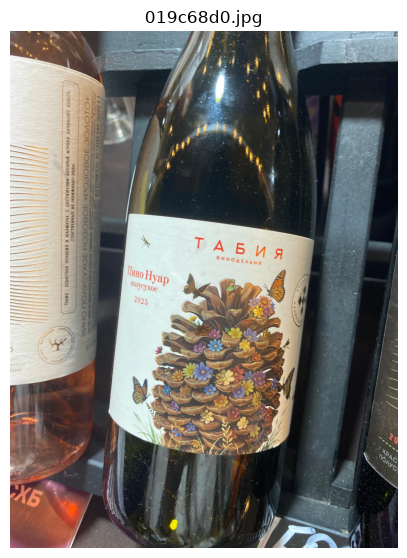

Ответ: False best: usadba-mezyb-usadba-mezyb-shardone-beloe-suhoe-125 p= 0.0088 threshold= 0.03 guard= twin_warning
OCR: ТАБИЯ ВИНОДЕЛЬНЯ ПиноНуар полусухое 2025


,item_id,probability,winery,name
0,usadba-mezyb-usadba-mezyb-shardone-beloe-suhoe...,0.008778,Усадьба Мезыбь,Усадьба Мезыбь. Шардоне
1,usadba-mezyb-usadba-mezyb-roze-kaberne-sovinon...,0.004760,Усадьба Мезыбь,Усадьба Мезыбь. Розе Каберне Совиньон
2,usadba-mezyb-usadba-mezyb-vione-beloe-suhoe-118,0.004610,Усадьба Мезыбь,Усадьба Мезыбь. Вионье
3,usadba-mezyb-usadba-mezyb-kaberne-sovinon-kras...,0.004137,Усадьба Мезыбь,Усадьба Мезыбь. Каберне Совиньон
4,usadba-mezyb-usadba-mezyb-merlo-krasnoe-suhoe-15,0.003531,Усадьба Мезыбь,Усадьба Мезыбь. Мерло


In [9]:
# Измените только эту строку. Поддерживаются JPG, PNG, WEBP и HEIC при наличии декодера.
CUSTOM_IMAGE = ROOT / 'data/eval/queries/019c68d0.jpg'
custom_result = show_inference(CUSTOM_IMAGE)


## Визуальная сводка таблиц и ошибок

Табличные метрики ниже даны ещё и в графической форме. Для ошибок добавлен контактный лист:
он связывает агрегат с реальным изображением и кандидатом, на котором возник вердикт.

In [ ]:
out = pd.DataFrame(records('eval/results/platform_recrop_outcomes_paddle_current_test.jsonl'))
if len(out):
    out['error_kind'] = np.select(
        [out.known & ~out.final_top1 & out.answered, out.known & ~out.answered,
         ~out.known & out.answered],
        ['wrong known', 'refusal known', 'false accept unknown'], default='safe outcome')
    pd.crosstab(out['group'], out['error_kind']).plot.bar(stacked=True, figsize=(11, 4),
        title='Итоговые таблицы ошибок: визуальная сводка')
    plt.ylabel('кадры'); plt.tight_layout(); plt.show()
    from wine_scanner.embed import load_image
    gallery = out[out.error_kind != 'safe outcome'].head(12)
    fig, axes = plt.subplots(3, 4, figsize=(15, 12)); axes = axes.flat
    for axis, row in zip(axes, gallery.itertuples()):
        axis.imshow(load_image(row.path)); axis.axis('off')
        axis.set_title(f'{Path(row.path).name}\n{row.error_kind}\n→ {row.best_id[:28]}',
                       fontsize=8)
    for axis in axes[len(gallery):]: axis.axis('off')
    plt.tight_layout(); plt.show()

### Вывод визуальной сводки

График отвечает на вопрос «сколько и где», а контактный лист — «почему именно». Менять
production-модель следует только после проверки обеих перспектив: метрик по группам и
конкретных ошибок на изображениях.